# ChemKAN data generation — step-by-step walkthrough

This notebook walks through **how the two reproduction datasets are built**, one
intermediate step at a time, so a reviewer can see *what* each stage produces
before the full `.npz` archives are written.

It does **not** re-implement anything. Every step calls the same functions that
the command-line generators use:

| script | what it does |
|---|---|
| `common.py` | RNG, min/max normalization, noise, diagnostics, I/O |
| `reactor.py` | one 0-D Cantera autoignition trajectory |
| `generate_biodiesel.py` | isothermal transesterification dataset |
| `generate_hydrogen.py` | hydrogen–air autoignition dataset |
| `verify_data.py` | post-generation sanity checks |

So the notebook is a *readable trace* of the CLI, not a second copy of it.
Running `generate_all.py` writes the same arrays this notebook shows in memory.

**Environment:** run with the project `.venv` (Cantera 3.0.0, NumPy 1.26.4,
SciPy 1.17.1) plus `matplotlib`. See `requirements.txt` / `requirements-dev.txt`.

## 0. Setup

Put the generator directory on the import path and pull in the exact modules the
CLI uses. No logic is redefined below this cell.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt

# The generators live in this directory and import each other by bare name
# (e.g. `from common import ...`), so add it to sys.path and import from there.
DATA_GEN = Path.cwd()
if not (DATA_GEN / "common.py").exists():          # allow running from repo root
    DATA_GEN = Path.cwd() / "chemkan" / "scripts" / "data_gen"
    if not (DATA_GEN).exists():
        DATA_GEN = Path.cwd() / "chemkan-tuwien" / "chemkan" / "scripts" / "data_gen"
sys.path.insert(0, str(DATA_GEN))

import common
import reactor
import generate_biodiesel as bd
import generate_hydrogen as hy
import verify_data

print("data-generation directory:", DATA_GEN.name)
print("common module:", Path(common.__file__).name)
print("reactor module:", Path(reactor.__file__).name)

data-generation directory: data_gen
common module: common.py
reactor module: reactor.py


## 1. Biodiesel (transesterification)

Six species and three irreversible reactions, implemented here using second-order mass-action kinetics from the paper:
$$\text{TG}+\text{ROH}\xrightarrow{k_1}\text{DG}+\text{R'CO}_2\text{R},\\
  \text{DG}+\text{ROH}\xrightarrow{k_2}\text{MG}+\text{R'CO}_2\text{R},\\
  \text{MG}+\text{ROH}\xrightarrow{k_3}\text{GL}+\text{R'CO}_2\text{R}$$

### 1a. Model constants — straight from the paper

In [2]:
print("species :", bd.SPECIES)
print("Ea (kcal/mol):", bd.EA_KCAL)
print("ln(A)        :", bd.LN_A)
print("R  (kcal/mol/K):", bd.R_KCAL, " <- kcal units because Ea is in kcal/mol")

species : ['TG', 'ROH', 'DG', 'MG', 'GL', 'RCO2R']
Ea (kcal/mol): [14.54  6.47 14.42]
ln(A)        : [18.6   7.93 19.13]
R  (kcal/mol/K): 0.001987204259  <- kcal units because Ea is in kcal/mol


### 1b. Arrhenius rate constants at one temperature

In [3]:
T_demo = 334.8  # K, temperature of the unseen Figure 3 reference condition
k = bd.rate_constants(T_demo)
for name, ki in zip(("k1", "k2", "k3"), k):
    print(f"  {name}(T={T_demo:.1f} K) = {ki:.4e}")

  k1(T=334.8 K) = 3.8609e-02
  k2(T=334.8 K) = 1.6618e-01
  k3(T=334.8 K) = 7.8558e-02


### 1c. Random initial conditions used for dataset generation

The complete biodiesel dataset is generated by randomly sampling TG, ROH, and
temperature from the ranges reported in the paper. The other four species
start at zero.

This random sampling is used for the 20 training and 10 testing trajectories.
The fixed Figure 3 condition is evaluated separately in the following section.

In [4]:
rng = common.make_rng(0)

sample_y0, sample_T = bd.sample_initial_conditions(
    n=3,
    rng=rng,
)

print("Three example randomly sampled conditions:\n")

for i in range(len(sample_y0)):
    print(
        f"case {i}: "
        f"TG0={sample_y0[i, 0]:.4f}, "
        f"ROH0={sample_y0[i, 1]:.4f}, "
        f"T={sample_T[i]:.2f} K"
    )

    print(
        "        remaining initial species =",
        sample_y0[i, 2:],
    )

# Verify the paper's sampling ranges.
assert np.all((sample_y0[:, 0] >= 0.5) & (sample_y0[:, 0] <= 2.0))
assert np.all((sample_y0[:, 1] >= 0.5) & (sample_y0[:, 1] <= 2.0))
assert np.all((sample_T >= 323.0) & (sample_T <= 343.0))
assert np.allclose(sample_y0[:, 2:], 0.0)

print("\nSampling-range checks: PASS")

Three example randomly sampled conditions:

case 0: TG0=1.4554, ROH0=0.5248, T=335.13 K
        remaining initial species = [0. 0. 0. 0.]
case 1: TG0=0.9047, ROH0=1.7199, T=337.59 K
        remaining initial species = [0. 0. 0. 0.]
case 2: TG0=0.5615, ROH0=1.8691, T=333.87 K
        remaining initial species = [0. 0. 0. 0.]

Sampling-range checks: PASS


### 1d. Figure 3 reference-condition ground truth

Figure 3 of the ChemKAN paper uses the following unseen biodiesel condition:

- TG = 1.94
- ROH = 1.43
- DG = MG = GL = R'CO2R = 0
- T = 334.8 K

The following calculation integrates this fixed condition with the reference
ODE model. It reproduces the clean ground-truth trajectory for the condition
used in Figure 3; it does not yet reproduce the learned ChemKAN prediction.

Figure 3 reference trajectory shape: (30, 6)
Initial condition: {'TG': 1.94, 'ROH': 1.43, 'DG': 0.0, 'MG': 0.0, 'GL': 0.0, 'RCO2R': 0.0}
Temperature: 334.8 K


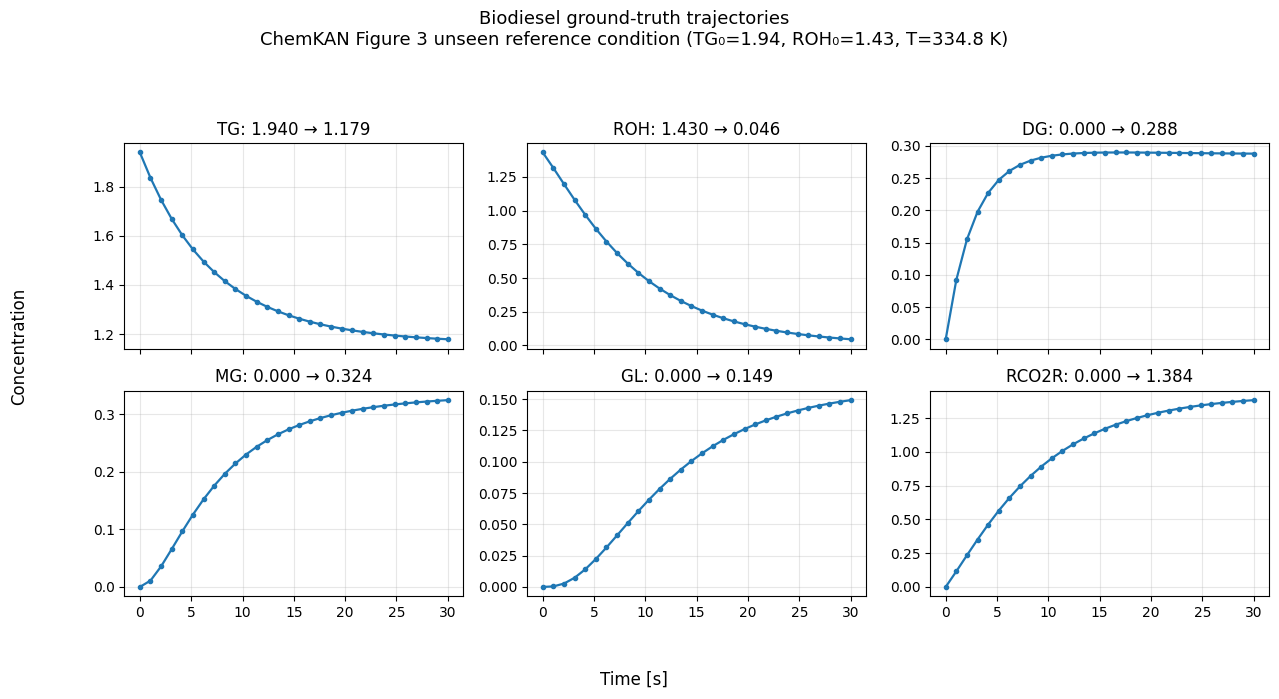

In [5]:
# Exact unseen initial condition reported in ChemKAN Figure 3.
fig3_y0 = np.array(
    [
        1.94,  # TG
        1.43,  # ROH
        0.0,   # DG
        0.0,   # MG
        0.0,   # GL
        0.0,   # RCO2R
    ],
    dtype=float,
)

fig3_T = 334.8  # K

# Same 30-second window and 30 saved points used for the biodiesel dataset.
t_bd = np.linspace(
    0.0,
    30.0,
    30,
)

fig3_states = bd.integrate_case(
    y0=fig3_y0,
    T=fig3_T,
    t_eval=t_bd,
)

print(
    "Figure 3 reference trajectory shape:",
    fig3_states.shape,
)

print(
    "Initial condition:",
    dict(zip(bd.SPECIES, fig3_y0)),
)

print("Temperature:", fig3_T, "K")

# One subplot for each species.
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13, 7),
    sharex=True,
)

for ax, species, values in zip(
    axes.flat,
    bd.SPECIES,
    fig3_states.T,
):
    ax.plot(
        t_bd,
        values,
        marker="o",
        markersize=3,
        linewidth=1.6,
    )

    ax.set_title(
        f"{species}: {values[0]:.3f} → {values[-1]:.3f}"
    )

    ax.grid(alpha=0.3)

fig.suptitle(
    "Biodiesel ground-truth trajectories\n"
    "ChemKAN Figure 3 unseen reference condition "
    "(TG₀=1.94, ROH₀=1.43, T=334.8 K)",
    fontsize=13,
)

fig.supxlabel("Time [s]")
fig.supylabel("Concentration")

fig.tight_layout(
    rect=(0.04, 0.04, 1.0, 0.92),
)

plt.show()

### 1e. The full dataset — one call to `generate()`

In [6]:
# SimpleNamespace mirrors the argparse defaults of
# generate_biodiesel.main().
cfg_bd = SimpleNamespace(
    seed=0,
    n_train=20,
    n_test=10,
    t_end=30.0,
    n_points=30,
    noise_levels=[
        0.0,
        0.01,
        0.02,
        0.05,
        0.07,
        0.10,
        0.15,
    ],
    noise_mode="multiplicative",
)

data_bd = bd.generate(cfg_bd)

print("keys:", sorted(data_bd.keys()))

print(
    "train_states:",
    data_bd["train_states"].shape,
    "(cases, times, species)",
)

print(
    "test_states:",
    data_bd["test_states"].shape,
)

# Reconstruct each trajectory's sampled condition:
# [initial TG, initial ROH, constant temperature].
train_ic = np.column_stack(
    [
        data_bd["train_states"][:, 0, 0],
        data_bd["train_states"][:, 0, 1],
        data_bd["train_T"],
    ]
)

test_ic = np.column_stack(
    [
        data_bd["test_states"][:, 0, 0],
        data_bd["test_states"][:, 0, 1],
        data_bd["test_T"],
    ]
)

n_unique_train = np.unique(
    train_ic,
    axis=0,
).shape[0]

n_unique_test = np.unique(
    test_ic,
    axis=0,
).shape[0]

print(
    "\nunique training conditions:",
    n_unique_train,
    "/",
    cfg_bd.n_train,
)

print(
    "unique testing conditions:",
    n_unique_test,
    "/",
    cfg_bd.n_test,
)

print("\nfirst three training conditions:")
print(train_ic[:3])

print("\nfirst three testing conditions:")
print(test_ic[:3])

# Check the sampling ranges.
lower = np.array([0.5, 0.5, 323.0])
upper = np.array([2.0, 2.0, 343.0])

assert np.all(train_ic >= lower)
assert np.all(train_ic <= upper)
assert np.all(test_ic >= lower)
assert np.all(test_ic <= upper)

# Every generated condition should be unique.
assert n_unique_train == cfg_bd.n_train
assert n_unique_test == cfg_bd.n_test

# Products/intermediates must start at zero.
assert np.allclose(
    data_bd["train_states"][:, 0, 2:],
    0.0,
)

assert np.allclose(
    data_bd["test_states"][:, 0, 2:],
    0.0,
)

# Check that no testing condition is duplicated in training.
train_test_matches = np.all(
    np.isclose(
        train_ic[:, None, :],
        test_ic[None, :, :],
        rtol=0.0,
        atol=1e-12,
    ),
    axis=2,
)

assert not train_test_matches.any()

print("\nDataset structure and diversity checks: PASS")

keys: ['mechanism', 'metadata', 'noise_levels', 'species', 'state_layout', 't', 'test_T', 'test_states', 'test_states_noise00', 'test_states_noise01', 'test_states_noise02', 'test_states_noise05', 'test_states_noise07', 'test_states_noise10', 'test_states_noise15', 'train_T', 'train_states', 'train_states_noise00', 'train_states_noise01', 'train_states_noise02', 'train_states_noise05', 'train_states_noise07', 'train_states_noise10', 'train_states_noise15', 'true_Ea_kcal', 'true_lnA', 'u_max', 'u_min']
train_states: (20, 30, 6) (cases, times, species)
test_states: (10, 30, 6)

unique training conditions: 20 / 20
unique testing conditions: 10 / 10

first three training conditions:
[[  1.45544253   0.54247951 334.43059661]
 [  0.90468007   0.68642491 329.43738782]
 [  0.56146029   1.50593662 334.8860006 ]]

first three testing conditions:
[[  1.10682776   1.44366223 338.15457691]
 [  0.79776957   1.89073183 332.94845391]
 [  0.63612957   1.16056573 333.5862432 ]]

Dataset structure and di

### 1f. Train-only normalization

In [7]:
u_min, u_max = data_bd["u_min"], data_bd["u_max"]
print("fitted on TRAIN only (no test leakage):")
for s, lo, hi in zip(bd.SPECIES, u_min, u_max):
    print(f"  {s:>6}: min {lo:.4f}  max {hi:.4f}")

hat = common.normalize(data_bd["train_states"], u_min, u_max)
print("\nnormalized train range: [%.3f, %.3f]  (expected within [0, 1])"
      % (hat.min(), hat.max()))

fitted on TRAIN only (no test leakage):
      TG: min 0.1804  max 1.9026
     ROH: min 0.0107  max 1.9958
      DG: min 0.0000  max 0.3217
      MG: min 0.0000  max 0.3551
      GL: min 0.0000  max 0.3194
   RCO2R: min 0.0000  max 1.8600

normalized train range: [0.000, 1.000]  (expected within [0, 1])


### 1g. Synthetic noise (multiplicative Gaussian; t=0 kept clean)

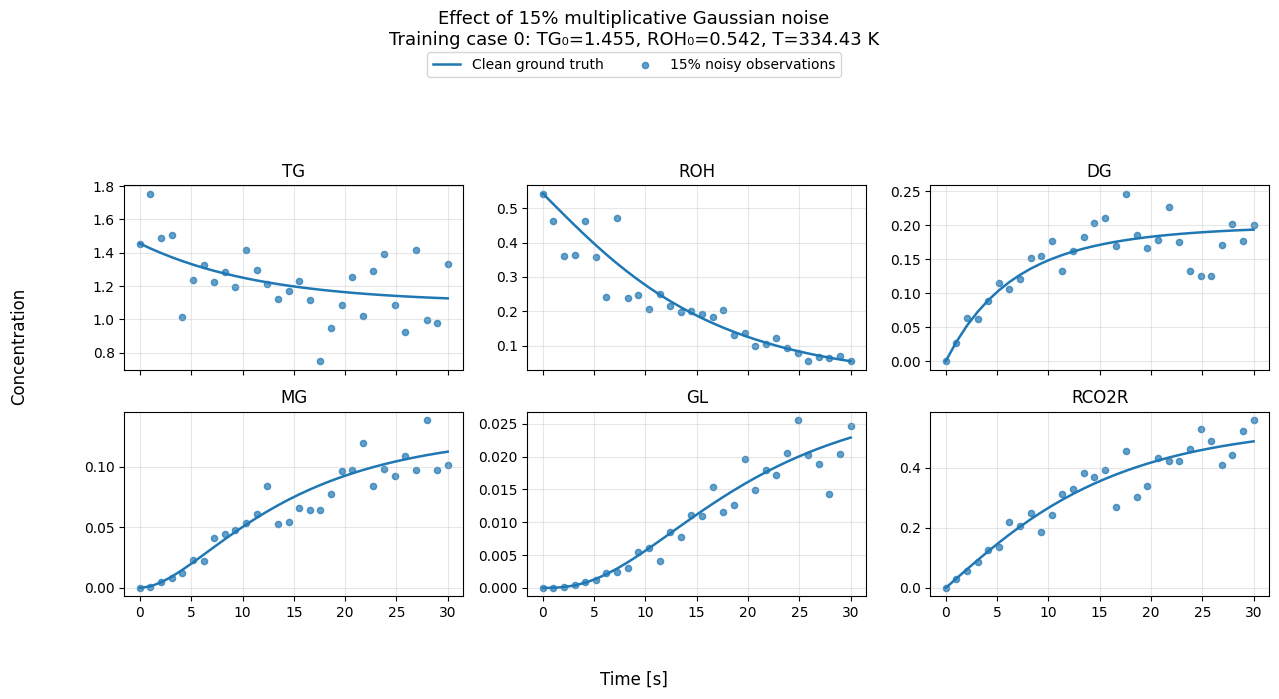

All t=0 states remain clean: PASS


In [8]:
clean = data_bd["train_states"]
noisy = data_bd["train_states_noise15"]

# Visualize the first randomly generated training trajectory.
case = 0
time_bd = data_bd["t"]

tg0 = clean[case, 0, 0]
roh0 = clean[case, 0, 1]
temperature = data_bd["train_T"][case]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13, 7),
    sharex=True,
)

for species_index, ax in enumerate(axes.flat):
    species = bd.SPECIES[species_index]

    ax.plot(
        time_bd,
        clean[case, :, species_index],
        linewidth=1.8,
        label="Clean ground truth",
    )

    ax.scatter(
        time_bd,
        noisy[case, :, species_index],
        s=20,
        alpha=0.7,
        label="15% noisy observations",
    )

    ax.set_title(species)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Effect of 15% multiplicative Gaussian noise\n"
    f"Training case {case}: "
    f"TG₀={tg0:.3f}, ROH₀={roh0:.3f}, "
    f"T={temperature:.2f} K",
    fontsize=13,
)

fig.supxlabel("Time [s]")
fig.supylabel("Concentration")

# One shared legend instead of six repeated legends.
handles, labels = axes.flat[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.93),
)

fig.tight_layout(
    rect=(0.04, 0.04, 1.0, 0.86),
)

plt.show()

# The noise implementation intentionally keeps the full initial
# condition exact.
assert np.allclose(
    clean[:, 0, :],
    noisy[:, 0, :],
)

print("All t=0 states remain clean: PASS")

### 1h. Assembling the ChemKAN model input (append constant T)

In [9]:
u_in = common.with_temperature(data_bd["train_states"], data_bd["train_T"])
print("states          :", data_bd["train_states"].shape, " [Y_1..Y_6]")
print("+ appended T col :", u_in.shape, " [Y_1..Y_6, T]  (20, 30, 7)")
temperature_is_constant = np.allclose(
    u_in[..., -1],
    data_bd["train_T"][:, None],
)

assert temperature_is_constant

print(
    "Temperature column is constant within every trajectory: PASS"
)

states          : (20, 30, 6)  [Y_1..Y_6]
+ appended T col : (20, 30, 7)  [Y_1..Y_6, T]  (20, 30, 7)
Temperature column is constant within every trajectory: PASS


### 1i. Verification — reuse `verify_data.check_biodiesel`

In [10]:
ok = verify_data.check_biodiesel(data_bd)

assert ok, "Biodiesel verification failed."

print("\nBiodiesel checks: PASS")

  [PASS] max negative concentration: 0.000e+00 (tol 1e-10)
  [PASS] glyceride backbone drift: 2.442e-15 (tol 1e-07)
  [PASS] ROH consumed vs ester produced: 1.998e-15 (tol 1e-07)
  [PASS] train normalized below 0: 0.000e+00 (tol 1e-12)
  [PASS] train normalized above 1: 0.000e+00 (tol 1e-12)
  info: noise 0% -> empirical sigma 0.000
  info: noise 1% -> empirical sigma 0.010
  info: noise 2% -> empirical sigma 0.020
  info: noise 5% -> empirical sigma 0.051
  info: noise 7% -> empirical sigma 0.071
  info: noise 10% -> empirical sigma 0.099
  info: noise 15% -> empirical sigma 0.149

Biodiesel checks: PASS


## 2. Hydrogen–air autoignition

A zero-dimensional, adiabatic, **constant-pressure** reactor is integrated with
Cantera using `h2o2.yaml`. The stored state retains the nine species (excluding Ar) and
temperature. Ar is omitted from the saved state because it has zero abundance
for the selected H₂/air composition.

Temperature is an evolving state, and ignition appears as a sharp thermal
runaway.

### 2a. Mechanism and retained species

In [11]:
names, keep = reactor.species_index(hy.MECH, hy.DROP)
print("mechanism:", hy.MECH)
print("species  :", names, f"({len(names)} kept; dropped {hy.DROP})")

mechanism: h2o2.yaml
species  : ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'N2'] (9 kept; dropped ('AR',))


### 2b. A single autoignition trajectory

trajectory shape (times, species+T): (601, 10)


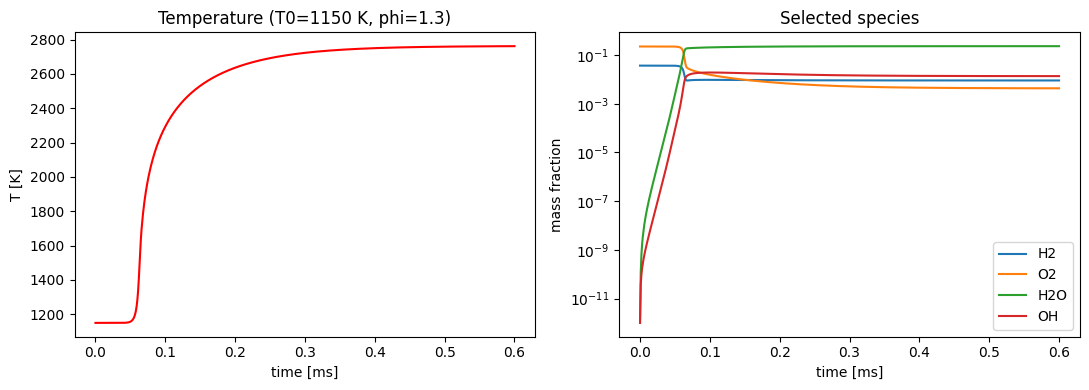

In [12]:
import cantera as ct
t_h2 = np.linspace(0.0, 0.6e-3, 601)             # dense here just to see the shape
# T0_demo, phi_demo = 1100.0, 1.0
T0_demo, phi_demo = hy.TEST_IC
one = reactor.integrate_case(hy.MECH, hy.FUEL, hy.OXIDIZER, T0_demo, phi_demo,
                             t_h2, ct.one_atm, keep)
print("trajectory shape (times, species+T):", one.shape)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(t_h2 * 1e3, one[:, -1], "r-")
a1.set(xlabel="time [ms]", ylabel="T [K]", title=f"Temperature (T0={T0_demo:.0f} K, phi={phi_demo})")
for sp in ("H2", "O2", "H2O", "OH"):
    j = names.index(sp)
    a2.semilogy(t_h2 * 1e3, np.clip(one[:, j], 1e-12, None), label=sp)
a2.set(xlabel="time [ms]", ylabel="mass fraction", title="Selected species")
a2.legend(); plt.tight_layout(); plt.show()

### 2c. The full coarse grid — `generate()`

In [13]:
# Mirrors generate_hydrogen.main() defaults for the coarse (train/test) grid.
cfg_h2 = SimpleNamespace(
    seed=0, grid="coarse", t_end=0.6e-3, n_points=50, ignition_points=601,
    phis=None, pressure=ct.one_atm, rtol=1e-9, atol=1e-15,
)
data_h2 = hy.generate(cfg_h2)

print("\nstates      :", data_h2["states"].shape, " (36 cases, 50 saved points, 9+T)")
print("train_states:", data_h2["train_states"].shape)
print("test_states :", data_h2["test_states"].shape, " -> held out:", data_h2["test_ics"])

  mechanism h2o2.yaml: 9 species, 29 reactions
  species: ['H2', 'H', 'O', 'O2', 'OH', 'H2O', 'HO2', 'H2O2', 'N2']
  Note: using 6 equivalence ratios including phi=0.5; the prose lists 5.
        This matches the reported 36 cases and Fig. 8 range.
  36 cases | 35 train / 1 test
  30/36 ignited within 0.60 ms
  ignition delay computed on 601-point diagnostic grid
  T range: 950-2781 K
  stiffness proxy (worst case): 8.5e+15

states      : (36, 50, 10)  (36 cases, 50 saved points, 9+T)
train_states: (35, 50, 10)
test_states : (1, 50, 10)  -> held out: [[1150.     1.3]]


### 2d. Ignition delay

Ignition delay is defined as the time of maximum $dT/dt$. It is evaluated on a
dense 601-point diagnostic grid rather than the coarse 50-point saved grid.
This reduces the time discretization from approximately 12.2 μs to 1 μs.
The diagnostic value is therefore more precise, although it is still
discretized by the dense grid.

30/36 cases ignited within 0.6 ms


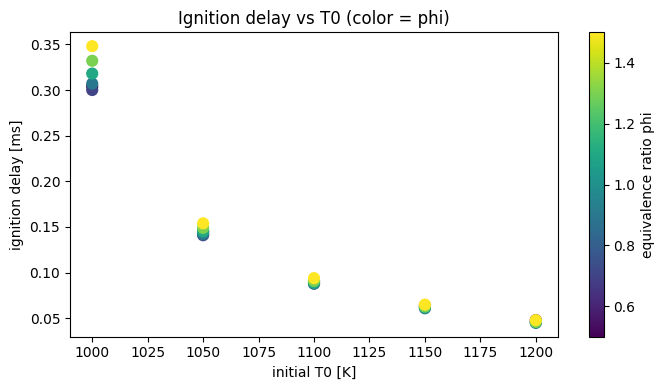

In [14]:
ics = data_h2["ics"]
tau = data_h2["ignition_delay"]
ignited = np.isfinite(tau)
print(f"{ignited.sum()}/{len(tau)} cases ignited within 0.6 ms")

fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(ics[ignited, 0], tau[ignited] * 1e3, c=ics[ignited, 1], cmap="viridis", s=60)
ax.set(xlabel="initial T0 [K]", ylabel="ignition delay [ms]", title="Ignition delay vs T0 (color = phi)")
plt.colorbar(sc, label="equivalence ratio phi"); plt.tight_layout(); plt.show()

### 2e. Verification — reuse `verify_data.check_combustion`

In [15]:
ok = verify_data.check_combustion(data_h2)

assert ok, "Hydrogen verification failed."

print("\nHydrogen checks: PASS")

  [PASS] max negative mass fraction: 0.000e+00 (tol 1e-10)
  [PASS] max |sum(Y) - 1|: 1.098e-13 (tol 1e-08)
  [PASS] max negative temperature: 0.000e+00 (tol 0e+00)
  [PASS] element H drift: 4.136e-15 (tol 1e-08)
  [PASS] element O drift: 1.110e-13 (tol 1e-08)
  [PASS] element N drift: 0.000e+00 (tol 1e-08)
  [PASS] train normalized below 0: 0.000e+00 (tol 1e-12)
  [PASS] train normalized above 1: 0.000e+00 (tol 1e-12)
  info: 30/36 cases ignited

Hydrogen checks: PASS


## 3. Recap — what the CLI writes

Everything above was held in memory. The command-line entry points run the same
steps and persist the arrays with `common.save`:

```bash
python generate_biodiesel.py --out ../../data/generated/biodiesel.npz
python generate_hydrogen.py  --out ../../data/generated/hydrogen.npz
python generate_all.py                 # both of the above
python verify_data.py ../../data/generated/hydrogen.npz
```

**Shared conventions** (see `common.py` docstring and the README):

- **Normalization** — one min/max per variable, fitted on the *clean training
  set only*, reused for train/test/noisy/predictions (no test leakage).
- **Noise** — multiplicative Gaussian, `u·(1+σ·ε)`, documented implementation
  choice; the initial condition is left exact.
- **Reproducibility** — every `.npz` stores concise `metadata` (seed, mechanism,
  species, time grid, library versions, git commit).
- **Figure 3 reference condition** — the fixed condition
  `[TG, ROH, DG, MG, GL, R'CO2R] = [1.94, 1.43, 0, 0, 0, 0]`
  at `T = 334.8 K` is evaluated separately from dataset generation. It is not
  substituted for the randomly generated training and testing conditions.